# 07 — Live Prediction Exploration

Purpose: inspect the live inference step (`src/ml/predict.py`) that
didn't exist yet when notebook 04 was first built. `feature_engineering.py`'s
risk_label is forward-looking, so the MOST RECENT row per ticker always
has a null label -- there's no future data yet to compute it from. That
null-label row is exactly the "today" prediction the dashboard needs,
and this notebook lets you inspect it before trusting `run_inference()`
in production.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import yaml
import pandas as pd

from src.ml.predict import (
    load_model_bundle, load_feature_table, get_latest_rows, run_inference,
)
from src.ml.train import FEATURE_COLUMNS

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

ml_config = config["ml"]
bucket = config["s3"]["bucket"]


## 1. Load the saved model bundle (model + scaler + label encoder)

In [3]:
bundle = load_model_bundle(ml_config["model_version"], bucket)
print("Model type:", type(bundle["model"]).__name__)
print("Features:", bundle["features"])
print("Labels:", bundle["labels"])
print("Encoder classes:", bundle["encoder"].classes_)

Model type: XGBClassifier
Features: ['daily_return', 'volatility_20d', 'volatility_60d', 'volatility_90d', 'ma_20d', 'ma_60d', 'ma_90d', 'rsi_14', 'macd_line', 'macd_signal', 'daily_sentiment', 'sentiment_3d_avg', 'article_count']
Labels: ['Low', 'Medium', 'High']
Encoder classes: ['High' 'Low' 'Medium']


## 2. Load the feature table and isolate the live (null-label) rows

In [4]:
df = load_feature_table(bucket, config["s3"]["paths"]["processed_features"])
latest = get_latest_rows(df)

print(f"{len(latest)} tickers, {latest['risk_label'].isna().sum()} with a null (live) risk_label")
latest[["ticker", "date", "risk_label"] + FEATURE_COLUMNS[:4]].head(10)


150 tickers, 150 with a null (live) risk_label


,ticker,date,risk_label,daily_return,volatility_20d,volatility_60d,volatility_90d
0,SCHAEFFLER,2026-07-24,None,0.003543,0.011613,0.015296,0.019699
1,BHEL,2026-07-24,None,0.018799,0.025018,0.024352,0.024829
2,ABBOTINDIA,2026-07-24,None,-0.001034,0.011832,0.013952,0.014374
3,POLYCAB,2026-07-24,None,-0.003078,0.018259,0.018051,0.019885
4,ASHOKLEY,2026-07-24,None,0.002788,0.016909,0.024555,0.028537
5,GROWW,2026-07-24,None,-0.001728,0.026135,0.024017,0.028871
6,FLUOROCHEM,2026-07-24,None,-0.000765,0.023024,0.017969,0.020783
7,LGEINDIA,2026-07-24,None,-0.000916,0.011069,0.014115,0.019212
8,NHPC,2026-07-24,None,-0.010717,0.011886,0.017089,0.017006
9,FORTIS,2026-07-24,None,0.006418,0.013424,0.013339,0.015285


Every row here should have a null `risk_label` -- that confirms the
forward-looking label design is behaving as expected (see
`feature_engineering.add_forward_volatility_label`). If some rows
DO have a non-null label, your feature table's "latest" date isn't
actually the most recent trading day -- worth checking the ETL run
that produced it.


## 3. Check for incomplete feature rows (these get skipped by predict.py)


In [5]:
incomplete = latest[latest[FEATURE_COLUMNS].isna().any(axis=1)]
print(f"{len(incomplete)} / {len(latest)} tickers have at least one missing feature and will be SKIPPED")
incomplete[["ticker"] + FEATURE_COLUMNS].head(10)


0 / 150 tickers have at least one missing feature and will be SKIPPED


,ticker,daily_return,volatility_20d,volatility_60d,volatility_90d,ma_20d,ma_60d,ma_90d,rsi_14,macd_line,macd_signal,daily_sentiment,sentiment_3d_avg,article_count


## 4. Run live inference via the production function

In [ ]:
predictions = run_inference(
    config_path=CONFIG_PATH
)

print(f"{len(predictions)} live predictions written to S3")
predictions.head(10)

## 5. Distribution of live predictions -- sanity check against the training-time class balance


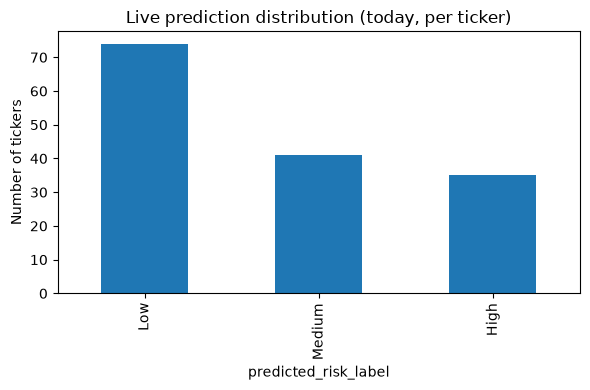

In [10]:
import matplotlib.pyplot as plt

predictions["predicted_risk_label"].value_counts().reindex(bundle["labels"]).plot(
    kind="bar", figsize=(6, 4), title="Live prediction distribution (today, per ticker)"
)
plt.ylabel("Number of tickers")
plt.tight_layout()
plt.show()

Compare this shape to the training-set label distribution you saw in
notebook 04 -- a live distribution wildly different from the training
distribution (e.g. everything predicted "Low" when training was
roughly balanced) is worth investigating before trusting the dashboard's
numbers; it usually means either today's market conditions are
genuinely unusual, or a feature computed differently live vs. at
training time (e.g. a rolling window with less history available).


## 6. Spot-check one ticker's full reasoning trail

In [11]:
sample_ticker = predictions["ticker"].iloc[0]
row = latest[latest["ticker"] == sample_ticker].iloc[0]
pred_row = predictions[predictions["ticker"] == sample_ticker].iloc[0]

print(f"Ticker: {sample_ticker}")
print(f"Date: {row['date']}")
print(f"Predicted risk label: {pred_row['predicted_risk_label']}")
print()
print("Feature values driving this prediction:")
for col in FEATURE_COLUMNS:
    print(f"  {col}: {row[col]:.4f}" if pd.notna(row[col]) else f"  {col}: NaN")


Ticker: SCHAEFFLER
Date: 2026-07-24
Predicted risk label: Low

Feature values driving this prediction:
  daily_return: 0.0035
  volatility_20d: 0.0116
  volatility_60d: 0.0153
  volatility_90d: 0.0197
  ma_20d: 4127.6351
  ma_60d: 4120.0017
  ma_90d: 4080.1488
  rsi_14: 46.7514
  macd_line: -25.9058
  macd_signal: -26.7052
  daily_sentiment: 0.0000
  sentiment_3d_avg: 0.0000
  article_count: 0.0000
